Step 0, Loss: 6237998592.0
Step 50, Loss: 69219712.0
Step 100, Loss: 37389808.0
Step 150, Loss: 27955424.0
Step 200, Loss: 23075930.0
Step 250, Loss: 20096856.0


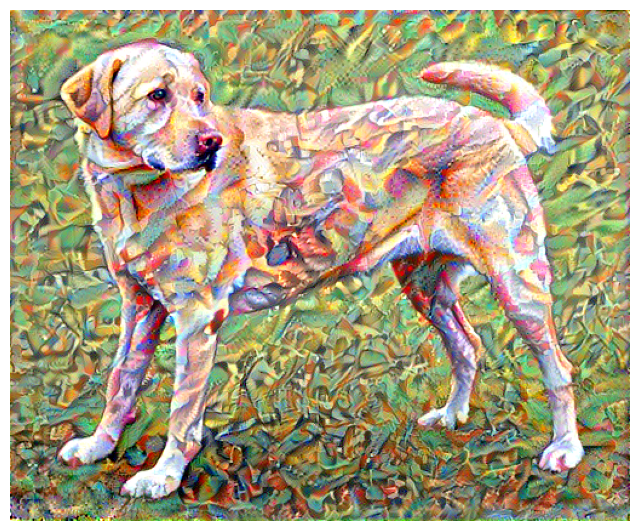

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.models import Model

content_path = tf.keras.utils.get_file(
    "content.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)

style_path = tf.keras.utils.get_file(
    "style.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg"
)

def load_image(path, max_dim=512):
    img = tf.keras.preprocessing.image.load_img(path)
    img = tf.keras.preprocessing.image.img_to_array(img)
    long = max(img.shape)
    scale = max_dim / long
    img = tf.image.resize(img,
                          (int(img.shape[0]*scale),
                           int(img.shape[1]*scale)))
    img = tf.expand_dims(img, axis=0)
    return preprocess_input(img)

content_image = load_image(content_path)
style_image = load_image(style_path)

vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

content_layer = ['block5_conv2']
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

outputs = [vgg.get_layer(name).output for name in (style_layers + content_layer)]
model = Model([vgg.input], outputs)

def content_loss(content, generated):
    return tf.reduce_mean(tf.square(content - generated))

def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    shape = tf.shape(input_tensor)
    num_locations = tf.cast(shape[1]*shape[2], tf.float32)
    return result / num_locations

def style_loss(style, generated):
    gram_style = gram_matrix(style)
    gram_generated = gram_matrix(generated)
    return tf.reduce_mean(tf.square(gram_style - gram_generated))

content_weight = 1e4
style_weight = 1e-2

style_targets = model(style_image)[:len(style_layers)]
content_target = model(content_image)[len(style_layers)]

def total_loss(outputs):
    style_outputs = outputs[:len(style_layers)]
    content_output = outputs[len(style_layers)]
    s_loss = 0
    for s, g in zip(style_targets, style_outputs):
        s_loss += style_loss(s, g)
    c_loss = content_loss(content_target, content_output)
    return style_weight * s_loss + content_weight * c_loss

generated_image = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.optimizers.Adam(learning_rate=5.0)

@tf.function()
def train_step():
    with tf.GradientTape() as tape:
        outputs = model(generated_image)
        loss = total_loss(outputs)
    grads = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grads, generated_image)])
    return loss

epochs = 300

for i in range(epochs):
    loss = train_step()
    if i % 50 == 0:
        print(f"Step {i}, Loss: {loss.numpy()}")

def deprocess(img):
    img = img.numpy()
    img = img.reshape(img.shape[1], img.shape[2], 3)
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype('uint8')
    return img

plt.figure(figsize=(8,8))
plt.imshow(deprocess(generated_image))
plt.axis("off")
plt.show()